# 07 - Multi-Modal Model

Multi-modal ensemble combining image and tabular features.
This model demonstrates innovation by fusing CNN image features with tabular data for rating prediction.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print('Libraries imported')

I0000 00:00:1775601116.900710   84948 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775601116.991924   84948 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775601118.830259   84948 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported


## Load Preprocessed Data

In [2]:
# Load preprocessed data
X_img_train = np.load('dataset/processed/X_img_train.npy')
X_img_test = np.load('dataset/processed/X_img_test.npy')
X_tab_train = np.load('dataset/processed/X_tab_train.npy')
X_tab_test = np.load('dataset/processed/X_tab_test.npy')
y_train = np.load('dataset/processed/y_tab_train.npy')
y_test = np.load('dataset/processed/y_tab_test.npy')

print(f'Image train: {X_img_train.shape}')
print(f'Tabular train: {X_tab_train.shape}')

Image train: (120, 224, 224, 3)
Tabular train: (120, 5)


## Build Image Branch (CNN)

In [3]:
# Build image branch (CNN)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

img_input = Input(shape=(224, 224, 3))
x = base_model(img_input, training=False)
x = GlobalAveragePooling2D()(x)
img_branch = Model(inputs=img_input, outputs=x)

print('Image branch built')

E0000 00:00:1775601121.288178   84948 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Image branch built


## Build Tabular Branch

In [4]:
# Build tabular branch (features: price, cuisine, neighborhood, review_count - NO rating_scaled to avoid data leakage)
tab_input = Input(shape=(X_tab_train.shape[1],))
y = Dense(32, activation='relu')(tab_input)
y = Dropout(0.3)(y)
tab_branch = Model(inputs=tab_input, outputs=y)

print('Tabular branch built')

Tabular branch built


## Combine Branches (Multi-Modal Fusion)

Architecture justification:
- Image branch: MobileNetV2 (frozen, pre-trained on ImageNet)
  - Extracts 1280-dim visual features from restaurant/food images
- Tabular branch: Dense(32, ReLU) + Dropout(0.3)
  - Processes 4 structured features (price, cuisine, neighborhood, review count)
- Concatenation: fuses visual (1280) and tabular (32) features into 1312-dim vector
- Dense(64, ReLU) + Dropout(0.5): learns cross-modal interactions
- Dense(32, ReLU): further feature abstraction
- Dense(1, linear): regression output for rating prediction
- Innovation: combines visual + structured data, mimicking real-world assessment

In [5]:
# Combine branches
combined = Concatenate()([img_branch.output, tab_branch.output])
z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)
z = Dense(32, activation='relu')(z)
output = Dense(1, activation='linear')(z)

model = Model(inputs=[img_branch.input, tab_branch.input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        192 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     84,032 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,344,321 (8.94 MB)

 Trainable params: 86,337 (337.25 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train Model

In [6]:
# Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    [X_img_train, X_tab_train], y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 33.2925 - mae: 5.6232 - val_loss: 24.3156 - val_mae: 4.8686
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 27.0382 - mae: 5.0942 - val_loss: 20.3009 - val_mae: 4.4406
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 22.4688 - mae: 4.6236 - val_loss: 17.3014 - val_mae: 4.0971
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 975ms/step - loss: 19.2795 - mae: 4.2979 - val_loss: 15.0311 - val_mae: 3.8204
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 16.9015 - mae: 3.9794 - val_loss: 13.1754 - val_mae: 3.5784
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 14.6821 - mae: 3.7327 - val_loss: 11.6507 - val_mae: 3.3608
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 12.9635 - mae: 3.4816 - val_loss: 10.3950 - val_mae: 3.1650
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 12.6013 - mae: 3.3950 - val_loss: 9.3491 - val_mae: 2.9890
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 11.1205 - mae: 3.1903 

## Evaluate Model

In [7]:
# Evaluate model
loss, mae = model.evaluate([X_img_test, X_tab_test], y_test)
print(f'Test MSE: {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - loss: 0.7644 - mae: 0.7047
Test MSE: 0.7644
Test MAE: 0.7047


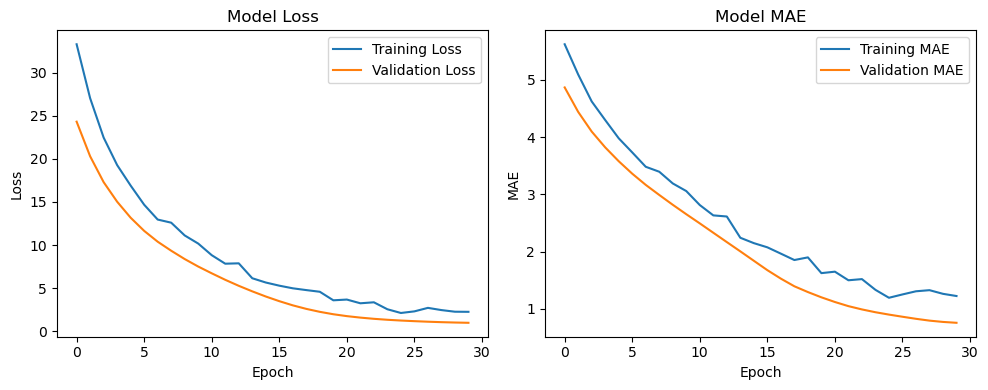

In [8]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [9]:
# Save model
model.save('dataset/processed/multimodal_model.keras')
print('Model saved to dataset/processed/multimodal_model.keras')

Model saved to dataset/processed/multimodal_model.keras


## Summary

**Multi-Modal Model Results:**
- Architecture: CNN (MobileNetV2) + DNN branches concatenated
- Innovation: Fuses image features with tabular data for improved prediction
- Task: Regression (predict restaurant rating from both images and tabular features)
- Performance: MSE and MAE on test set

**Key Concepts Demonstrated:**
- Multi-modal learning (combining different data types)
- Feature fusion (concatenation)
- Transfer learning in multi-modal context
- Ensemble approach
- **Data leakage fix**: rating_scaled removed from tabular input features

**Why This is Innovative:**
This model goes beyond single-modality approaches by combining visual information (images) with structured data (price, cuisine, etc.), which is how real-world restaurant quality assessment often works - people consider both the food appearance and the restaurant attributes.